<a href="https://colab.research.google.com/github/renataovalentim/tcc-mba-uspesalq-data-science/blob/main/Resultados_TCC_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importação dos pacotes necessários
import pandas as pd #manipulação de dados em formato de dataframe
import numpy as np #biblioteca para operações matemáticas multidimensionais
from scipy.stats import skew #cálculo da assimetria
from scipy.stats import kurtosis #cálculo da curtose
import seaborn as sns #biblioteca de visualização de informações estatísticas
import matplotlib.pyplot as plt #biblioteca de visualização de dados
from scipy.stats import norm #para plotagem da distribuição normal no histograma
from scipy.stats import chi2_contingency #estatística qui-quadrado
from scipy.stats.contingency import association #medidas de associação
from scipy.stats import pearsonr #cálculo da correlação de Pearson
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [ ]:
# Baixar dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uom190346a/mental-health-diagnosis-and-treatment-monitoring")

print("Path to dataset files:", path)

100%|██████████| 10.3k/10.3k [00:00<00:00, 17.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uom190346a/mental-health-diagnosis-and-treatment-monitoring/versions/1


In [ ]:
# Carregar dados
df = pd.read_csv('/content/drive/MyDrive/Projeto de pesquisa/mental_health_diagnosis_treatment_.csv', delimiter=',')

In [ ]:
df

,Patient ID,Age,Gender,Diagnosis,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Medication,Therapy Type,Treatment Start Date,Treatment Duration (weeks),Stress Level (1-10),Outcome,Treatment Progress (1-10),AI-Detected Emotional State,Adherence to Treatment (%)
0,1,43,Female,Major Depressive Disorder,10,5,8,5,Mood Stabilizers,Interpersonal Therapy,2024-01-25,11,9,Deteriorated,7,Anxious,66
1,2,40,Female,Major Depressive Disorder,9,5,4,7,Antipsychotics,Interpersonal Therapy,2024-02-27,11,7,No Change,7,Neutral,78
2,3,55,Female,Major Depressive Disorder,6,3,4,3,SSRIs,Mindfulness-Based Therapy,2024-03-20,14,7,Deteriorated,5,Happy,62
3,4,34,Female,Major Depressive Disorder,6,3,6,5,SSRIs,Mindfulness-Based Therapy,2024-03-29,8,8,Deteriorated,10,Excited,72
4,5,52,Male,Panic Disorder,7,6,6,8,Anxiolytics,Interpersonal Therapy,2024-03-18,12,5,Deteriorated,6,Excited,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,24,Male,Generalized Anxiety,10,4,8,6,Mood Stabilizers,Dialectical Behavioral Therapy,2024-04-09,8,9,Improved,10,Depressed,73
496,497,22,Male,Panic Disorder,5,6,6,7,Benzodiazepines,Mindfulness-Based Therapy,2024-02-05,13,6,Deteriorated,8,Happy,86
497,498,23,Male,Major Depressive Disorder,7,3,4,2,Antidepressants,Cognitive Behavioral Therapy,2024-03-24,10,5,Deteriorated,5,Neutral,87
498,499,48,Male,Bipolar Disorder,9,4,6,9,Antidepressants,Mindfulness-Based Therapy,2024-03-22,10,6,Improved,7,Anxious,73


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Patient ID                    500 non-null    int64 
 1   Age                           500 non-null    int64 
 2   Gender                        500 non-null    object
 3   Diagnosis                     500 non-null    object
 4   Symptom Severity (1-10)       500 non-null    int64 
 5   Mood Score (1-10)             500 non-null    int64 
 6   Sleep Quality (1-10)          500 non-null    int64 
 7   Physical Activity (hrs/week)  500 non-null    int64 
 8   Medication                    500 non-null    object
 9   Therapy Type                  500 non-null    object
 10  Treatment Start Date          500 non-null    object
 11  Treatment Duration (weeks)    500 non-null    int64 
 12  Stress Level (1-10)           500 non-null    int64 
 13  Outcome             

In [ ]:
df.nunique()

,0
Patient ID,500
Age,43
Gender,2
Diagnosis,4
Symptom Severity (1-10),6
Mood Score (1-10),6
Sleep Quality (1-10),6
Physical Activity (hrs/week),10
Medication,6
Therapy Type,4


In [ ]:
df.describe()

,Patient ID,Age,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Treatment Duration (weeks),Stress Level (1-10),Treatment Progress (1-10),Adherence to Treatment (%)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,250.500000,38.708000,7.478000,5.482000,6.472000,5.216000,12.110000,7.542000,7.436000,75.45400
std,144.481833,12.712433,1.706265,1.707486,1.668167,2.829374,2.440864,1.709409,1.725067,9.08697
min,1.000000,18.000000,5.000000,3.000000,4.000000,1.000000,8.000000,5.000000,5.000000,60.00000
25%,125.750000,28.000000,6.000000,4.000000,5.000000,3.000000,10.000000,6.000000,6.000000,67.00000
50%,250.500000,38.000000,8.000000,5.000000,6.000000,5.000000,12.000000,8.000000,7.000000,76.00000
75%,375.250000,50.000000,9.000000,7.000000,8.000000,8.000000,14.000000,9.000000,9.000000,84.00000
max,500.000000,60.000000,10.000000,8.000000,9.000000,10.000000,16.000000,10.000000,10.000000,90.00000


Figuras 1 a 6

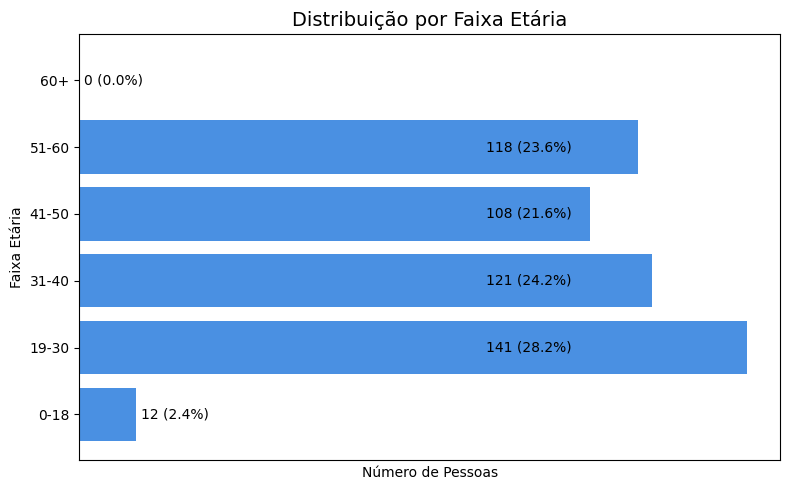

In [ ]:
# Criar faixas etárias
faixas_etarias = pd.cut(df['Age'], bins=[0, 18, 30, 40, 50, 60, 100], labels=['0-18', '19-30', '31-40', '41-50', '51-60', '60+'])

# Contagem por faixa etária
faixa_counts = faixas_etarias.value_counts().sort_index()

# Calcular o percentual
faixa_percent = (faixa_counts / faixa_counts.sum() * 100).round(1)

# Criar gráfico de barras horizontais para a faixa etária com subplots (gerando o objeto ax)
fig, ax = plt.subplots(figsize=(8, 5))

# Criar as barras
bars = ax.barh(faixa_counts.index, faixa_counts.values, color='#4A90E2')  # Barra azul sem borda preta
ax.set_title('Distribuição por Faixa Etária', fontsize=14)
ax.set_xlabel('Número de Pessoas')
ax.set_ylabel('Faixa Etária')

# Adicionar os percentuais nas barras horizontais
for bar, count, percent in zip(bars, faixa_counts.values, faixa_percent.values):
    # Definir a posição do texto para que ele não ultrapasse o limite
    x_position = bar.get_width() + 1  # Posição inicial do percentual à direita da barra

    # Limitar o texto dentro da área do gráfico (ajustando se necessário)
    if x_position + 50 > max(faixa_counts.values):  # Evitar ultrapassar a largura total
        x_position = max(faixa_counts.values) - 55  # Ajustar para não ultrapassar

    # Adicionar o percentual ao lado da barra
    ax.text(x_position, bar.get_y() + bar.get_height() / 2,
             f'{count} ({percent}%)',
             va='center', ha='left', fontsize=10)

# Remover rótulos do eixo X
ax.set_xticks([])

# Ajustar layout
plt.tight_layout()
plt.show()


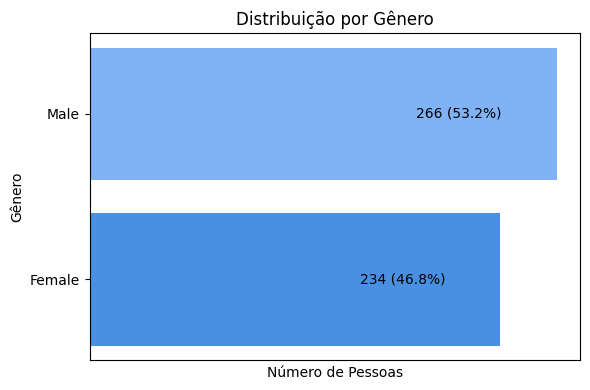

In [ ]:
# Gráfico distribuição por gênero

df['Gender'] = df['Gender'].str.strip().str.capitalize()

# Filtrar apenas os gêneros desejados
df = df[df['Gender'].isin(['Male', 'Female'])]

# Contagem por gênero
gender_counts = df['Gender'].value_counts().sort_index()

# Porcentagem por gênero
gender_percent = (gender_counts / gender_counts.sum() * 100).round(1)

# Cores em tons de azul
colors = ['#4A90E2', '#7FB3F5']

# Plotando o gráfico
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(gender_counts.index, gender_counts.values, color=colors)

# Adicionando os rótulos de contagem e percentual
for bar, count, percent in zip(bars, gender_counts.values, gender_percent.values):
    # Posição inicial do percentual à direita da barra
    x_position = bar.get_width() + 1

    # Ajustar o percentual para dentro da barra, garantindo que não ultrapasse a largura total
    if x_position + 20 > bar.get_width():  # Ajuste para evitar ultrapassar a largura total
        x_position = bar.get_width() - 80  # Ajuste para ficar dentro da barra

    # Adicionar o percentual ao lado da barra
    ax.text(x_position, bar.get_y() + bar.get_height() / 2,
            f'{count} ({percent}%)',
            ha='left', va='center', fontsize=10)

# Título e eixos
ax.set_title('Distribuição por Gênero')
ax.set_ylabel('Gênero')
ax.set_xlabel('Número de Pessoas')

# Remover rótulos do eixo X
ax.set_xticks([])

plt.tight_layout()
plt.show()


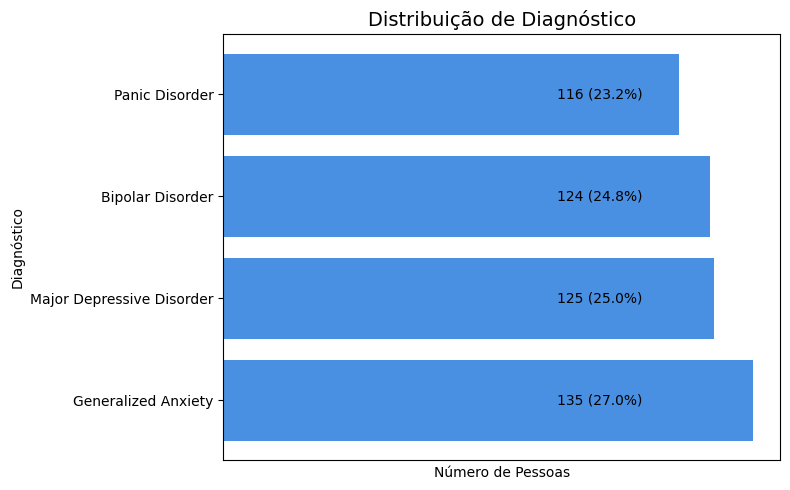

In [ ]:
# Contagem dos diagnósticos
diagnosis_counts = df['Diagnosis'].value_counts()

# Calcular o percentual
diagnosis_percent = (diagnosis_counts / diagnosis_counts.sum() * 100).round(1)

# Criar gráfico de barras horizontais com subplots (gerando o objeto ax)
fig, ax = plt.subplots(figsize=(8, 5))

# Criar as barras
bars = ax.barh(diagnosis_counts.index, diagnosis_counts.values, color='#4A90E2')  # Barra azul sem borda preta
ax.set_title('Distribuição de Diagnóstico', fontsize=14)
ax.set_xlabel('Número de Pessoas')
ax.set_ylabel('Diagnóstico')

# Adicionar os percentuais nas barras horizontais
for bar, count, percent in zip(bars, diagnosis_counts.values, diagnosis_percent.values):
    # Definir a posição do texto para que ele não ultrapasse o limite
    x_position = bar.get_width() + 1  # Posição inicial do percentual à direita da barra

    # Limitar o texto dentro da área do gráfico (ajustando se necessário)
    if x_position + 50 > max(diagnosis_counts.values):  # Evitar ultrapassar a largura total
        x_position = max(diagnosis_counts.values) - 50  # Ajustar para não ultrapassar

    # Adicionar o percentual ao lado da barra
    ax.text(x_position, bar.get_y() + bar.get_height() / 2,
             f'{count} ({percent}%)',
             va='center', ha='left', fontsize=10)

# Remover rótulos do eixo X
ax.set_xticks([])

# Ajustar layout
plt.tight_layout()
plt.show()


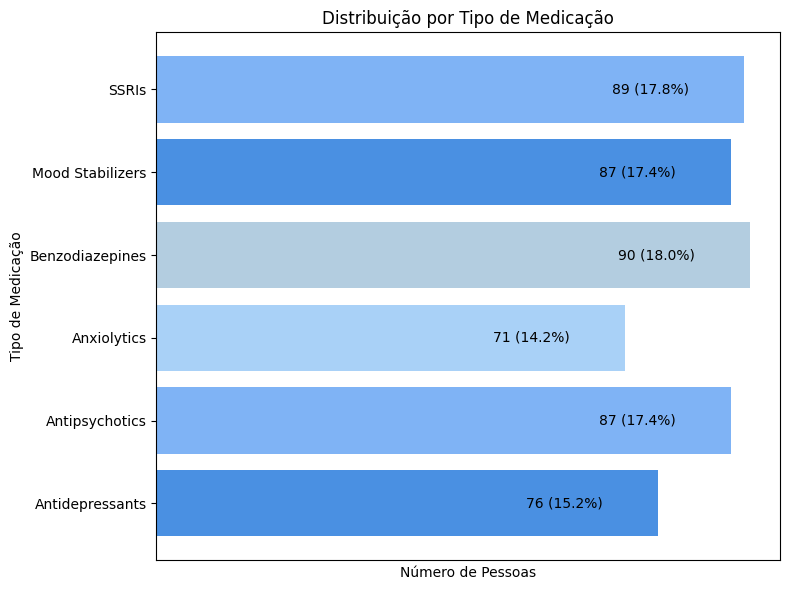

In [ ]:
# Gráfico distribuição por tipo de medicação

# Contagem por tipo de medicação
medication_counts = df['Medication'].value_counts().sort_index()

# Porcentagem por tipo de medicação
medication_percent = (medication_counts / medication_counts.sum() * 100).round(1)

# Cores em tons de azul (opcional)
colors = ['#4A90E2', '#7FB3F5', '#A9D1F7', '#B3CDE0']  # Ajuste conforme a quantidade de categorias

# Plotando o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(medication_counts.index, medication_counts.values, color=colors)

# Adicionando os rótulos de contagem e percentual
for bar, count, percent in zip(bars, medication_counts.values, medication_percent.values):
    # Posição do percentual: um pouco à direita da barra
    x_position = bar.get_width() + 1

    # Garantir que o percentual não ultrapasse a barra
    if x_position + 10 > bar.get_width():  # Ajuste para evitar ultrapassar a largura total
        x_position = bar.get_width() - 20  # Ajuste para ficar dentro da barra

    # Adicionar o texto de contagem e percentual dentro ou ao lado da barra
    ax.text(x_position, bar.get_y() + bar.get_height() / 2,
            f'{count} ({percent}%)',
            ha='left', va='center', fontsize=10)

# Título e eixos
ax.set_title('Distribuição por Tipo de Medicação')
ax.set_ylabel('Tipo de Medicação')
ax.set_xlabel('Número de Pessoas')

# Remover rótulos do eixo X
ax.set_xticks([])

plt.tight_layout()
plt.show()


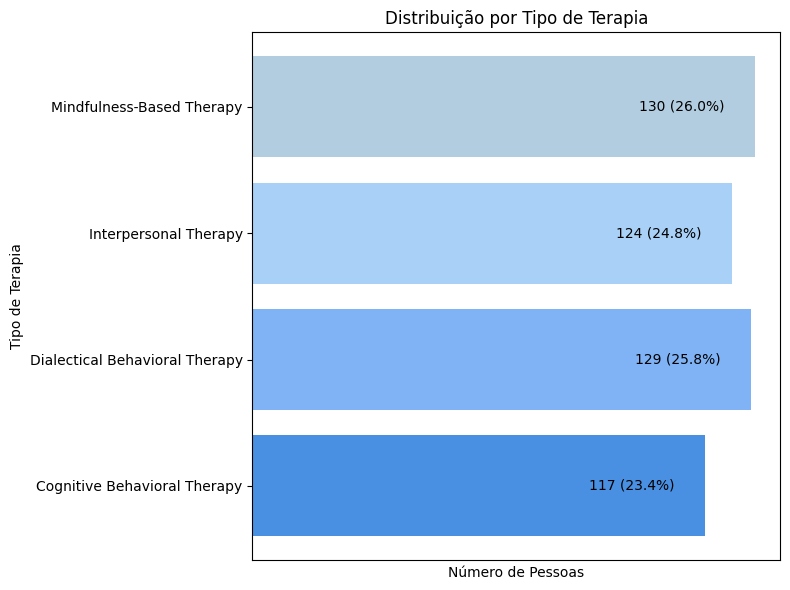

In [ ]:
# Gráfico distribuição por tipo de terapia

# Contagem por tipo de terapia
therapy_counts = df['Therapy Type'].value_counts().sort_index()

# Porcentagem por tipo de terapia
therapy_percent = (therapy_counts / therapy_counts.sum() * 100).round(1)

# Cores para o gráfico (opcional)
colors = ['#4A90E2', '#7FB3F5', '#A9D1F7', '#B3CDE0']  # Ajuste conforme a quantidade de categorias

# Plotando o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(therapy_counts.index, therapy_counts.values, color=colors)

# Adicionando os rótulos de contagem e percentual
for bar, count, percent in zip(bars, therapy_counts.values, therapy_percent.values):
    # Posição do percentual: um pouco à direita da barra
    x_position = bar.get_width() + 1

    # Garantir que o percentual não ultrapasse a barra
    if x_position + 10 > bar.get_width():  # Ajuste para evitar ultrapassar a largura total
        x_position = bar.get_width() - 30  # Ajuste para ficar dentro da barra

    # Adicionar o texto de contagem e percentual dentro ou ao lado da barra
    ax.text(x_position, bar.get_y() + bar.get_height() / 2,
            f'{count} ({percent}%)',
            ha='left', va='center', fontsize=10)

# Título e eixos
ax.set_title('Distribuição por Tipo de Terapia')
ax.set_ylabel('Tipo de Terapia')
ax.set_xlabel('Número de Pessoas')

# Remover rótulos do eixo X
ax.set_xticks([])

plt.tight_layout()
plt.show()


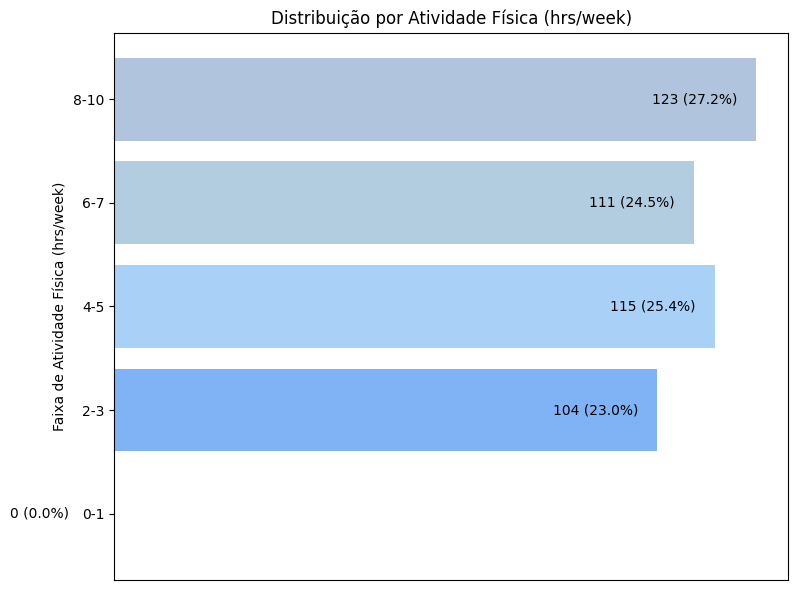

In [ ]:
# Gráfico distribuição por Atividade Física (hrs/week)

# Criar faixas de horas de atividade física considerando no máximo 10 horas
bins = [0, 1, 3, 5, 7, 10]  # Faixas de atividade física (máximo 10 horas)
labels = ['0-1', '2-3', '4-5', '6-7', '8-10']  # Definição dos rótulos das faixas

# Criar a coluna de faixas de atividade física
activity_bins = pd.cut(df['Physical Activity (hrs/week)'], bins=bins, labels=labels, right=False)

# Contagem por faixa de atividade física
activity_counts = activity_bins.value_counts().sort_index()

# Porcentagem por faixa de atividade física
activity_percent = (activity_counts / activity_counts.sum() * 100).round(1)

# Cores para o gráfico (opcional)
colors = ['#4A90E2', '#7FB3F5', '#A9D1F7', '#B3CDE0', '#B0C4DE']

# Plotando o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(activity_counts.index, activity_counts.values, color=colors)

# Adicionando os rótulos de contagem e percentual
for bar, count, percent in zip(bars, activity_counts.values, activity_percent.values):
    # Posição do percentual: um pouco à direita da barra
    x_position = bar.get_width() + 1

    # Garantir que o percentual não ultrapasse a barra
    if x_position + 10 > bar.get_width():  # Ajuste para evitar ultrapassar a largura total
        x_position = bar.get_width() - 20  # Ajuste para ficar dentro da barra

    # Adicionar o texto de contagem e percentual dentro ou ao lado da barra
    ax.text(x_position, bar.get_y() + bar.get_height() / 2,
            f'{count} ({percent}%)',
            ha='left', va='center', fontsize=10)

# Título e eixos
ax.set_title('Distribuição por Atividade Física (hrs/week)')
ax.set_ylabel('Faixa de Atividade Física (hrs/week)')

# Remover rótulos do eixo X
ax.set_xticks([])

plt.tight_layout()
plt.show()


Análises Estatísticas: Teste Qui-Quadrado e Medidas de Contingência

In [ ]:
# Tabela de contingência completa (com totais)
tabela_completa = pd.crosstab(
    df['Diagnosis'],
    df['Outcome'],
    margins=True,
    margins_name="Total"
)
print("Tabela Completa:")
display(tabela_completa)

Tabela Completa:


Outcome,Deteriorated,Improved,No Change,Total
Diagnosis,,,,
Bipolar Disorder,46,44,34,124
Generalized Anxiety,37,53,45,135
Major Depressive Disorder,44,32,49,125
Panic Disorder,44,41,31,116
Total,171,170,159,500


In [ ]:
# Tabela de contingência para análise
tabela_conting = pd.crosstab(
    df['Diagnosis'],
    df['Outcome']
)
print("\nTabela de Contingência:")
display(tabela_conting)


Tabela de Contingência:


Outcome,Deteriorated,Improved,No Change
Diagnosis,,,
Bipolar Disorder,46,44,34
Generalized Anxiety,37,53,45
Major Depressive Disorder,44,32,49
Panic Disorder,44,41,31


In [ ]:
tabela_relativa_linha = pd.crosstab(
    df['Diagnosis'],
    df['Outcome'],
    normalize='index'  # Divide cada linha pelo total da linha
) * 100

print("\nTabela de Contingência Relativa por Linha (% por diagnóstico):")
display(tabela_relativa_linha.round(2))


Tabela de Contingência Relativa por Linha (% por diagnóstico):


Outcome,Deteriorated,Improved,No Change
Diagnosis,,,
Bipolar Disorder,37.10,35.48,27.42
Generalized Anxiety,27.41,39.26,33.33
Major Depressive Disorder,35.20,25.60,39.20
Panic Disorder,37.93,35.34,26.72


In [ ]:
# Teste Qui-Quadrado
chi2, pvalor, df_gl, freq_esp = chi2_contingency(tabela_conting)
print("\nTeste Qui-Quadrado:")
display(pd.DataFrame({
    'Qui-quadrado': [chi2],
    'Graus de liberdade': [df_gl],
    'p-value': [pvalor]
}))


Teste Qui-Quadrado:


,Qui-quadrado,Graus de liberdade,p-value
0,10.409079,6,0.108449


In [ ]:
# Resíduos
print("\nResíduos (Observado - Esperado):")
residuos = tabela_conting - freq_esp
display(residuos)


Resíduos (Observado - Esperado):


Outcome,Deteriorated,Improved,No Change
Diagnosis,,,
Bipolar Disorder,3.592,1.84,-5.432
Generalized Anxiety,-9.170,7.10,2.070
Major Depressive Disorder,1.250,-10.50,9.250
Panic Disorder,4.328,1.56,-5.888


In [ ]:
residuos_padronizados = (tabela_conting - freq_esp) / np.sqrt(freq_esp)
print("\nResíduos Padronizados:")
display(residuos_padronizados)


Resíduos Padronizados:


Outcome,Deteriorated,Improved,No Change
Diagnosis,,,
Bipolar Disorder,0.551585,0.283379,-0.865038
Generalized Anxiety,-1.349551,1.047978,0.315929
Major Depressive Disorder,0.191180,-1.610626,1.467145
Panic Disorder,0.687140,0.248403,-0.969450


In [ ]:
# Medidas de Associação
print("\nMedidas de Associação:")
print("Coeficiente de Contingência:", association(tabela_conting, method='pearson'))
print("V de Cramer:", association(tabela_conting, method='cramer'))


Medidas de Associação:
Coeficiente de Contingência: 0.14280616431156207
V de Cramer: 0.10202489343103888


Relação entre Diagnóstico e Resultado:

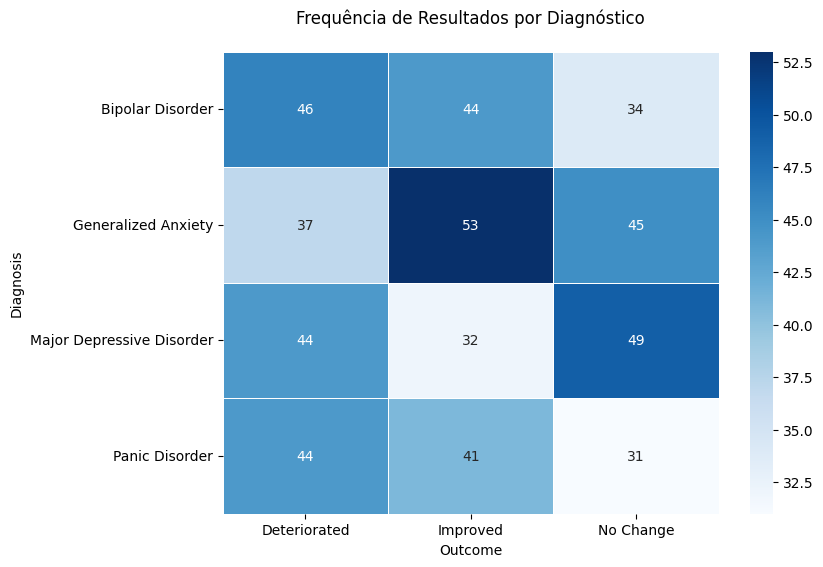

In [ ]:
# Mapa de Calor
plt.figure(figsize=(8, 6))
sns.heatmap(
    tabela_conting,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=.5
)
plt.title("Frequência de Resultados por Diagnóstico", pad=20)
plt.show()

Mapa de calor de correlações

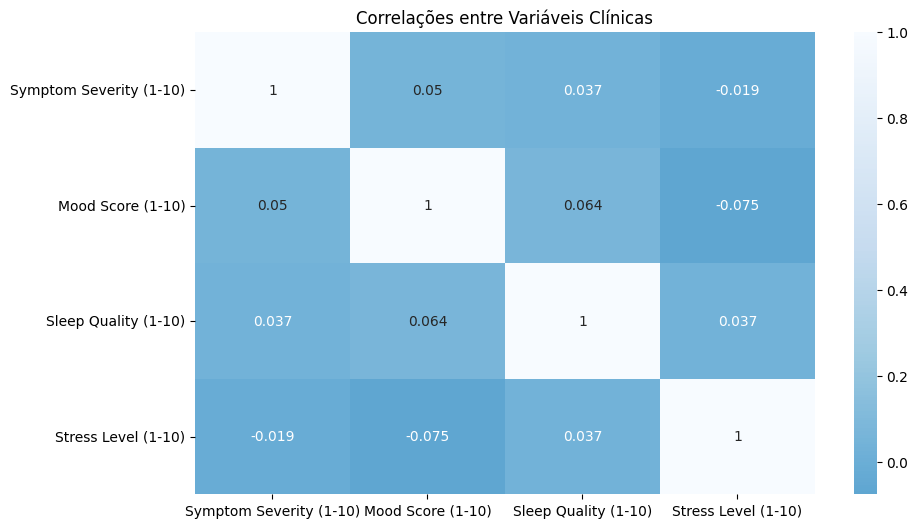

In [ ]:
# Mapa de calor de correlações
plt.figure(figsize=(10, 6))
corr_matrix = df[['Symptom Severity (1-10)', 'Mood Score (1-10)',
                  'Sleep Quality (1-10)', 'Stress Level (1-10)']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues_r', center=0)
plt.title('Correlações entre Variáveis Clínicas')
plt.show()

a)	Variáveis numéricas (Symptom Severity, Mood Score) seguem distribuição normal?

In [ ]:
from scipy.stats import shapiro, kstest

# Teste de Shapiro-Wilk (para n < 50)
stat, p = shapiro(df['Symptom Severity (1-10)'])
print(f"Symptom Severity - Shapiro: p = {p:.4f}")
# p > 0.05 → Não rejeita normalidade

# Teste de Kolmogorov-Smirnov (para n ≥ 50)
stat, p = kstest((df['Mood Score (1-10)'] - df['Mood Score (1-10)'].mean()) / df['Mood Score (1-10)'].std(), "norm")
print(f"Mood Score - KS: p = {p:.4f}")

Symptom Severity - Shapiro: p = 0.0000
Mood Score - KS: p = 0.0000


b)	Comparação da mediana do Symptom Severity entre diagnósticos usando Kruskal-Wallis:

In [ ]:
from scipy.stats import kruskal

# Preparar os grupos
grupos = []
for diagnostico in df['Diagnosis'].unique():
    grupos.append(df[df['Diagnosis'] == diagnostico]['Symptom Severity (1-10)'])

# Teste Kruskal-Wallis
h_stat, p_value = kruskal(*grupos)
print(f"Kruskal-Wallis: H = {h_stat:.2f}, p = {p_value:.4f}")

Kruskal-Wallis: H = 2.65, p = 0.4488


In [ ]:
#1. Analisar outra Variável Dependente Exemplo: Verificar se o Mood Score difere entre diagnósticos:

from scipy.stats import kruskal

grupos = [df[df['Diagnosis'] == d]['Mood Score (1-10)'] for d in df['Diagnosis'].unique()]
h_stat, p_value = kruskal(*grupos)
print(f"Kruskal-Wallis (Mood Score): H = {h_stat:.2f}, p = {p_value:.4f}")

Kruskal-Wallis (Mood Score): H = 2.05, p = 0.5627


In [ ]:
#2. Explorar Relações com Variáveis Categóricas Exemplo: Verificar se há associação entre Therapy Type e Outcome (Qui-Quadrado):
from scipy.stats import chi2_contingency

tabela = pd.crosstab(df['Therapy Type'], df['Outcome'])
chi2, p, dof, expected = chi2_contingency(tabela)
print(f"Qui-Quadrado: χ²({dof}) = {chi2:.2f}, p = {p:.4f}")

Qui-Quadrado: χ²(6) = 9.56, p = 0.1445


In [ ]:
#3. Correlacionar Variáveis Numéricas - Exemplo: Relação entre Sleep Quality e Stress Level (Spearman):
from scipy.stats import spearmanr

rho, p = spearmanr(df['Sleep Quality (1-10)'], df['Stress Level (1-10)'])
print(f"Spearman ρ = {rho:.3f}, p = {p:.4f}")

Spearman ρ = 0.038, p = 0.4025


In [ ]:
from scipy.stats import f_oneway, kruskal
import numpy as np

# Extrair grupos
grupos = [df[df['Diagnosis'] == d]['Stress Level (1-10)'] for d in df['Diagnosis'].unique()]

# ANOVA (se normalidade for confirmada)
f_stat, p_anova = f_oneway(*grupos)

# Kruskal-Wallis (não paramétrico)
h_stat, p_kruskal = kruskal(*grupos)

print(f"ANOVA: F = {f_stat:.2f}, p = {p_anova:.4f}")
print(f"Kruskal-Wallis: H = {h_stat:.2f}, p = {p_kruskal:.4f}")

ANOVA: F = 0.19, p = 0.9055
Kruskal-Wallis: H = 0.58, p = 0.9007


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# Criando a tabela de contingência
tabela = pd.crosstab(df['Therapy Type'], df['Outcome'])

# Teste do qui-quadrado
chi2, p, dof, expected = chi2_contingency(tabela)

# Cálculo do V de Cramer
n = tabela.sum().sum()  # total de observações
min_dim = min(tabela.shape)  # menor entre número de linhas e colunas
phi_c = np.sqrt(chi2 / (n * (min_dim - 1)))

# Exibição dos resultados
print(f"Qui-Quadrado: χ²({dof}) = {chi2:.2f}, p = {p:.4f}")
print(f"V de Cramer: φc = {phi_c:.2f}")


Qui-Quadrado: χ²(6) = 9.56, p = 0.1445
V de Cramer: φc = 0.10


Tabela 6. Estatísticas descritivas das variáveis por diagnóstico:

In [ ]:
import pandas as pd

# Estatísticas descritivas por grupo
desc_stats = df.groupby('Diagnosis')['Stress Level (1-10)'].agg(['median', 'mean', 'std', 'count'])
print(desc_stats)

                           median      mean       std  count
Diagnosis                                                   
Bipolar Disorder              8.0  7.588710  1.729759    124
Generalized Anxiety           8.0  7.474074  1.660919    135
Major Depressive Disorder     7.0  7.504000  1.739596    125
Panic Disorder                8.0  7.612069  1.728390    116
